# Paracetamol $\mu^{ex}$ and solubility in ethanol/water

A gradient-GP surface for $\mu^{ex}$ and the solubility it implies, from **four data files** and
four reference numbers held as constants at the top of the notebook.

- **Figure A** (`productionFigA_muex_v7`) — $\mu^{ex}$ over the composition plane, above its
  constant-solvent slices.
- **Figure B** (`productionFigB_solubility_v7`) — total $\mu$ with both solid levels, above the
  solubility it implies for **both polymorphs**.

## Inputs, in full

**Data (4 files, under `Paracetamo-Water-Ethanol/`)**

| file | what is taken from it |
|---|---|
| `S0_paracetamol_water_ethanol_303K.csv` | 262 compositions: $x_\mathrm{para}$, $x_\mathrm{water}$, $x_\mathrm{ethanol}$, the particle counts, and the six partial $S(0)$ as the production value plus `_split{1,2,3}`. The only measurement input — all of $\mu^{ex}$ comes from here, and the three split sets are the whole finite-sampling error term. |
| `Exp_para_sol/solubility_exp_jouyban2008_nagai1984_303K.csv` | literature solubilities at 30 °C in mol/L: Jouyban 2008 and Nagai 1984. |
| `Exp_para_sol/solubility_exp_assis2021_303K.csv` | literature solubilities at 30 °C: Assis 2021, in mol/kg and mol/L. |
| `Exp_para_sol/density_ethanol_water_303K_CRC.csv` | CRC ethanol–water solvent density at 30 °C, for the mol/L → mol/kg conversion. |

The three literature tables are used **only** for the experimental points in Figure B(b); nothing in the model touches them.

**Constants (this cell)** — the two FEP anchors and their $\sigma$; the two solid $\mu$ and their
$\sigma$; the GP hyperparameters; units, temperature and molar masses; the Monte Carlo settings.

**Code** — `diagnose_mu_ex_gp_para.py` (`load_s0`, `COLUMN_MAP`, `KBT`, `KCAL_2_EV`),
`directional_gpr.py` (`prepare_para_directional_data`),
`gpr_grad` (`DirectionalGradientGP` and the input-warped kernel) and `szero`
(the Kirkwood–Buff inversion behind the gradients).

## The reference values

| | kcal/mol | kJ/mol |
|---|---|---|
| $\mu^\mathrm{s,I}$ | −17.3864 ± 0.0413 | −72.7447 ± 0.1728 |
| $\mu^\mathrm{s,II}$ | −16.8401 ± 0.0403 | −70.4590 ± 0.1686 |
| anchor, water ($\mu^{ex}$) | −5.4947 ± 0.0900 | −22.9899 ± 0.3766 |
| anchor, ethanol ($\mu^{ex}$) | −15.8601 ± 0.0332 | −66.3589 ± 0.1389 |

The solid values are the $\mu(T)$ line fit through `Form N.csv` with that fit's standard error.
Recomputing them directly from the crystal free-energy runs gives −17.4271 ± 0.0470 and
−16.8711 ± 0.0237 instead — larger $\sigma$ for Form I but smaller for Form II, so neither set is
uniformly the more conservative one.

The anchor $\sigma$ are the FEP statistical errors, water interpolated to 30 °C.

**Hyperparameters.** We applied $\boldsymbol{\alpha}=(0, 0.125)$ and
$\boldsymbol{\theta}=(0.12, 0.13)$ along $(x_{\rm para}, x_{\rm eth})$, with uniform gradient
noise $\sigma_g = 0.10$ kJ/mol. They are only meaningful as the set tuned together.

## Uncertainty

Every band and every quoted uncertainty is **one standard deviation** over one Monte Carlo ensemble,
drawn symmetrically about the plotted central curve. Three sources go into it: the three
trajectory splits (a multiplier bootstrap over refits, which reproduces the split standard error
while perturbing whole surfaces), the two anchors (exact and free, because with $\sigma_f = 0$ the
posterior mean is affine in the anchor values), and $\mu_\mathrm{solid}$ (the crossing level, so it
enters the solubility only). Outside the bands: the ideal-gas reference the solid and the anchors
share, which cancels in the crossing; the GP's own posterior variance; the $S(0)$ inversion; and the
force field.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import matplotlib.ticker as mticker
from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.legend_handler import HandlerBase
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter

ANALYSES = Path.cwd()
import os
GPR_GRAD_ROOT = next(  # dir *containing* gpr_grad/
    c for c in ([Path(os.environ["GPR_GRAD_DIR"])] if os.environ.get("GPR_GRAD_DIR") else [])
    + [b / n for b in (Path("."), Path(".."))
       for n in ("GPR_grad", "GPR_grad-test_non-stationary")]
    if (c / "gpr_grad").is_dir())
sys.path[:0] = [str(ANALYSES), str(GPR_GRAD_ROOT)]

from diagnose_mu_ex_gp_para import COLUMN_MAP, KBT, KCAL_2_EV, load_s0
from directional_gpr import prepare_para_directional_data
from gpr_grad import DirectionalGradientGP, InputWarpedKernelFunction

torch.set_default_dtype(torch.float64)

TEMP_C = 30.0

USE_KJ = True

KCAL_2_KJ = 4.184
E_SCALE = KCAL_2_KJ if USE_KJ else 1.0   # kcal/mol -> the chosen unit
E_UNIT = "kJ/mol" if USE_KJ else "kcal/mol"
E_2_EV = KCAL_2_EV / E_SCALE             # eV per chosen unit: divide eV by this, not by KCAL_2_EV
KB_T = KBT / E_2_EV                      # k_BT in the chosen unit

# ---- THE GP -----------------------------------------------------------------------------
# Input-warped RBF, along (x_para, x_eth). SIGMA_G is in eV here (0.00103643 eV = 0.10 kJ/mol);
# the three were tuned together and are only meaningful as a set.
THETA, WARP_ALPHA, SIGMA_G = (0.12, 0.13), 0.125, 0.00103643

# ---- THE FOUR REFERENCE VALUES ----------------------------------------------------------
# Constants rather than file reads -- the FEP lists and the solid mu(T) tables reduce to these
# four numbers, which is what lets this notebook run off two data files. Each sigma is in the unit
# of the value it belongs to; everything downstream converts at the point of use, so the USE_KJ
# switch still governs what is printed and plotted.
#
# Anchors: FEP solvation of one paracetamol, as mu_ex at the box composition (x_para, x_ethanol).
# sigma is the FEP statistical error (water interpolated to 30 C, which has no run of its own).
ANCHORS = {
    "water":   ((0.00840336, 0.0),        -0.238273),   # eV
    "ethanol": ((0.01351351, 0.98648649), -0.687761),
}
SIGMA_ANCHOR_EV = {"water": 0.003903, "ethanol": 0.001440}   # eV
RHO_ANCHOR = 0.0    # the two FEP runs are independent simulations in different solvents

# Solid: chemical potential of each polymorph at 30 C, referenced to the same ideal gas the
# anchors are, with the standard error of the mu(T) line fit it comes from.
MU_SOLID_KCAL = {1: -17.3864, 2: -16.8401}                   # kcal/mol
SIGMA_MU_SOLID_KCAL = {1: 0.0413, 2: 0.0403}                 # kcal/mol

MU_SOLID = {form: MU_SOLID_KCAL[form] * E_SCALE for form in (1, 2)}
SIGMA_SOLID = {form: SIGMA_MU_SOLID_KCAL[form] * E_SCALE for form in (1, 2)}
SIGMA_ANCHOR = {k: SIGMA_ANCHOR_EV[k] / E_2_EV for k in ANCHORS}   # display unit
ANCHOR_KEYS = tuple(ANCHORS)     # the row order of Y_f in the fit, i.e. of the two W fields

# ---- MONTE CARLO ------------------------------------------------------------------------
# One ensemble drives every band: the mu_ex slices, the total-mu slices and the solubility curve
# all come from the same N_MC draws over the three error sources (trajectory splits,
# anchors, mu_solid), so the panels are mutually consistent.
N_MC = 2000            # draws; the sample s.d. is good to ~1.6% of itself at this N
MC_SEED = 20250803
MC_BATCH = 25          # samples per vectorised block on the SF_SOL x XP_SOL crossing grid
# Every band and every quoted uncertainty is one standard deviation over the ensemble, applied
# symmetrically about the plotted central curve. The sampled distributions are not all symmetric --
# the saturation crossing is non-linear, and the peak position is pinned against pure ethanol -- so
# where that matters the s.d. is a summary of a lopsided spread rather than a description of it.

M_H2O, M_ETOH = 18.0153, 46.068  # g/mol
M_PARA = 151.163                 # g/mol -- paracetamol; used by the weight-fraction conversions
DATA_DIR = Path("Paracetamo-Water-Ethanol") / "Exp_para_sol"
EXP_MOLAR_CSV = DATA_DIR / "solubility_exp_jouyban2008_nagai1984_303K.csv"
EXP_ASSIS_CSV = DATA_DIR / "solubility_exp_assis2021_303K.csv"
DENSITY_CSV = DATA_DIR / "density_ethanol_water_303K_CRC.csv"

print(f"energies in {E_UNIT}  (E_SCALE={E_SCALE:g}, kB_T={KB_T:.4f})")
print(f"GP: input-warped RBF, theta={THETA}, warp_alpha={WARP_ALPHA:+g}, sigma_g={SIGMA_G:g}")
for _k in ANCHOR_KEYS:
    print(f"anchor {_k:8s} mu_ex = {ANCHORS[_k][1] / E_2_EV:9.4f} +-{SIGMA_ANCHOR[_k]:.4f} {E_UNIT}"
          f"   at (x_para, x_eth) = {ANCHORS[_k][0]}")
for _f in (1, 2):
    print(f"solid Form {_f}   mu    = {MU_SOLID[_f]:9.4f} +-{SIGMA_SOLID[_f]:.4f} {E_UNIT}"
          f"   ({MU_SOLID_KCAL[_f]:.4f} +-{SIGMA_MU_SOLID_KCAL[_f]:.4f} kcal/mol)")

energies in kJ/mol  (E_SCALE=4.184, kB_T=2.5205)
GP: input-warped RBF, theta=(0.12, 0.13), warp_alpha=+0.125, sigma_g=0.00103643
anchor water    mu_ex =  -22.9899 +-0.3766 kJ/mol   at (x_para, x_eth) = (0.00840336, 0.0)
anchor ethanol  mu_ex =  -66.3589 +-0.1389 kJ/mol   at (x_para, x_eth) = (0.01351351, 0.98648649)
solid Form 1   mu    =  -72.7447 +-0.1728 kJ/mol   (-17.3864 +-0.0413 kcal/mol)
solid Form 2   mu    =  -70.4590 +-0.1686 kJ/mol   (-16.8401 +-0.0403 kcal/mol)


## Figure parameters

Sized for **half the A4 page width** (4.14 in of 8.27 in), so the figures go in at
`\includegraphics[width=0.5\textwidth]` with no rescaling and the type sizes below are the sizes
on the printed page: 11 pt for axis labels, 10 pt for ticks and keys. Serif throughout, with
mathtext in the matching face. Each figure is written as **PDF (vector) and PNG at 800 dpi**;
use the PDF in the manuscript.

In [2]:
A4_W = 8.27                  # in -- A4 is 210 mm wide
FIG_W = A4_W / 2             # in -- half the page width
FIG_H = FIG_W * 0.627        # the panel aspect ratios are kept as tuned, so the heights
FIG_H_SHORT = FIG_W * 0.507  # follow the width rather than being fixed in inches
FIGSIZE = (FIG_W, FIG_H)
DPI = 800          # the saved PDF/PNG
# Inline preview only; type sizes are in points, so this matches the saved 800-DPI layout.
DPI_INLINE = 150
FIG_DIR = Path(".")

plt.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI_INLINE,
    "savefig.dpi": DPI,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "figure.titlesize": 12,
    "lines.linewidth": 1.3,
    "axes.linewidth": 0.7,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "xtick.minor.size": 1.4, "ytick.minor.size": 1.4,
    "xtick.major.width": 0.7, "ytick.major.width": 0.7,
    "legend.frameon": False,
    "legend.handlelength": 1.4,
    "legend.handletextpad": 0.4,
    "legend.columnspacing": 0.9,
    "legend.labelspacing": 0.3,
    "axes.grid": False,
})

# The companion NaCl/methanol figure's palette, red -> purple, so the paracetamol and those
# figures read as one set. Its pink is replaced by an orange at x_eth = 0.1, which the red swallowed.
SLICES = (0.0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0)
SLICE_COLOR = dict(zip(SLICES, [
    "#d9042b",  # red
    "#F57C00",  # orange  <- the one substitution; Meth has #FE64A3 pink here
    "#FFD320",  # yellow
    "#4DAA57",  # green
    "#3b82ff",  # blue
    "#0B2D6B",  # dark navy
    "#A14EBF",  # purple
]))

CMAP = "inferno_r"                         # CVD-safe sequential
OUTSIDE = "#e4e4e4"                        # unsampled region
# Form I: a colour of its own, naming the same object in both panels of Figure B.
COLOR_FORM_I = "#C2185B"          
# Form II: deep cyan, so its thin dotted solid level in Figure B(a) stays visible (dE 35 from the
# nearest slice). The 0.6 and 0.8 slices are separated by lightness (L* 56 vs 20) rather than hue,
# which also survives greyscale printing.
COLOR_FORM_II = "#00ACC1"
FORM_COLOR = {1: COLOR_FORM_I, 2: COLOR_FORM_II}
FORM_NAME = {1: "Form 1", 2: "Form 2"}     # internal; the figures label by polymorph
FORM_LABEL = {1: r"Multi-comp S0 (I)", 2: r"Multi-comp S0 (II)"}

EXP_PLOT = ("Prakongpan", "Jouyban", "Assis")

# A published single-state-point FEP/BAR value: a calculation, not a measurement, so it is drawn
# apart from the experimental series -- one filled circle under their open markers, since in neat
# ethanol all three land within 0.17 mol/kg. Its temperature is in the label; it is not at 30 C.
FEP_REF = dict(x_eth=1.0, m=1.3, sd=0.3, marker="o", color="#bf5b04",
               label=r"FEP/BAR (I), 298.15 K")
# All three in black: open markers, so shape alone separates them from the polymorph colours.
EXP_STYLE = {"Jouyban":    dict(marker="s", color="black", label="Exp. Jouyban 2008 (I)"),
             "Prakongpan": dict(marker="^", color="black", label="Exp. Nagai 1984 (I)"),
             "Assis":      dict(marker="D", color="black", label="Exp. Assis 2021 (I)")}

M_PARA_XLIM = 5.0   # mol/kg -- shared by both curve panels; molality, so never scaled
SHADE_ALPHA = 0.30  # every +-1 standard-error band, in all three curve panels
# Some bands are thinner than a line width, where a fill of any alpha is invisible, so each band
# also gets its two +-sigma edges as thin lines.
BAND_EDGE_LW, BAND_EDGE_ALPHA = 0.6, 0.55


def shaded_band(ax, x, lo, hi, color, zorder=None):
    """A +-1 sigma band -- the fill and its two edges in one colour. Returns the fill artist,
    which is what `HandlerBandLine` keys on."""
    kw = {} if zorder is None else {"zorder": zorder}
    band = ax.fill_between(x, lo, hi, color=color, alpha=SHADE_ALPHA, lw=0, **kw)
    for y in (lo, hi):
        ax.plot(x, y, color=color, lw=BAND_EDGE_LW, alpha=BAND_EDGE_ALPHA, **kw)
    return band

X_ETH_LABEL = r"$x_\mathrm{eth}/(x_\mathrm{eth}+ x_\mathrm{water}) $ "
W_ETH_LABEL = r"wt% ethanol (solute free)"
M_PARA_LABEL = r"$m_\mathrm{para}$ [mol/kg]"

MU_EX_LABEL = rf"$\Delta\mu^\mathrm{{ex}}_\mathrm{{para}}$ [{E_UNIT}]"
MU_TOTAL_LABEL = rf"$\mu_\mathrm{{para}}$ [{E_UNIT}]"
MU_EX_MAP_LABEL = rf"$\mu^{{ex}}_\mathrm{{para}}$ [{E_UNIT}]"


def wt_pct_eth(x_eth):
    """Solvent-basis ethanol mole fraction -> weight% ethanol, solute free.

    The same basis as the CSV's own "EtOH %(w/w, solute free)" column and as the CRC density
    table indexed by it, so the experimental series, the density conversion and the x axis of
    Figure B(b) all sit on one definition. Solute free: the dissolved paracetamol is excluded
    from the mass, exactly as it is excluded from x_eth/(x_eth + x_water).
    """
    x = np.asarray(x_eth, float)
    return 100.0 * x * M_ETOH / (x * M_ETOH + (1.0 - x) * M_H2O)


def save(fig, stem):
    """Write both the vector (PDF, for the manuscript) and raster (PNG, for preview) copies."""
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{stem}.{ext}", dpi=DPI, bbox_inches="tight")


def slice_key(fig, slices, label_top=False, **kw):
    """Discrete x_ethanol key for the slice panels: one equal block per slice, label centred.

    Replaces a seven-entry legend with the footprint of a colorbar; `kw` goes to `fig.colorbar`,
    so pass either `ax=`/`location=` (outside the axes) or `cax=` (an inset).
    """
    bounds = np.arange(len(slices) + 1) - 0.5
    centres = [(bounds[i] + bounds[i + 1]) / 2.0 for i in range(len(bounds) - 1)]
    sm = ScalarMappable(cmap=ListedColormap([SLICE_COLOR[s] for s in slices]),
                        norm=BoundaryNorm(bounds, len(slices)))
    cb = fig.colorbar(sm, orientation="horizontal", ticks=centres, **kw)
    cb.set_ticklabels([f"{s:.1f}" for s in slices])
    # one point smaller than the legend text: seven labels rather than six now share the bar
    cb.ax.tick_params(labelsize=plt.rcParams["legend.fontsize"] - 1.0,
                      direction="in", length=3, width=0.8, pad=2.5)
    cb.ax.xaxis.set_minor_locator(mticker.NullLocator())
    if label_top:  # inset: title above the bar, tick labels below
        cb.ax.xaxis.set_label_position("top")
    # same size as the legend text, not the axis-label size a colorbar would default to
    cb.set_label(X_ETH_LABEL, labelpad=4, size=plt.rcParams["legend.fontsize"])
    cb.outline.set_linewidth(0.7)
    return cb


class HandlerBandLine(HandlerBase):
    """Legend key for a shaded band plus its centre line, drawn in the series' own colour."""

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height,
                       fontsize, trans):
        _, line = orig_handle
        color = line.get_color()
        return [Rectangle([xdescent, ydescent], width, height, facecolor=color,
                          alpha=SHADE_ALPHA, lw=0, transform=trans),
                Line2D([xdescent, xdescent + width], [ydescent + height / 2] * 2,
                       color=color, lw=line.get_linewidth(), transform=trans)]

# Right margin for a panel with a vertical colorbar: save() crops with bbox_inches="tight", so
# reserving ~0.51 in here holds the saved width at FIG_W instead of growing it to 4.69 in.
CBAR_RIGHT = 0.775

# Panel letters: bare, bold, outside the top-left corner.
PANEL_LABEL_KW = dict(fontsize=12, fontweight="bold", ha="left", va="bottom")


def panel_labels(axes, letters="ab", dx_in=0.52, y=1.0):
    """Bold letters a fixed distance, in inches, left of each panel's top-left corner.

    The offset is given in inches and converted per panel rather than passed straight to
    `transAxes`: Figures A and B do not have the same axes width -- A reserves a strip for its
    colorbar -- so one shared axes-fraction offset would put the letters at visibly different
    distances from the two, and on B would push them off the left edge of the canvas.
    """
    for ax, ltr in zip(axes, letters):
        width_in = ax.get_position().width * ax.figure.get_figwidth()
        ax.text(-dx_in / width_in, y, ltr, transform=ax.transAxes, **PANEL_LABEL_KW)


## $\mu^{ex}$ from the $S(0)$ gradients

The only cell that fits anything: four gradient-GP fits — the production one and one per trajectory
split — plus the two anchor sensitivity fields the Monte Carlo needs, the molality conversions, and
the sampled-domain boundary.

Each state point contributes derivatives of $\mu^{ex}$ obtained from the Kirkwood–Buff inversion of
its partial $S(0)$: two along the coordinate axes for a true ternary composition, one along the edge
tangent on a binary edge, where the 3×3 $S(0)$ is singular. The GP integrates them, and the two FEP
anchors fix the level — with $\sigma_f = 0$ they are interpolated exactly, which is what makes the
anchor uncertainty a linear map rather than a refit.

In [3]:
df = load_s0()
# solute-free solvent-basis ethanol mole fraction of every sampled composition; rounded to the
# nominal level so that compositions built to the same target collapse onto one x_ethanol
X_ETH_DATA = np.round((df.x_ethanol / (df.x_ethanol + df.x_water)).to_numpy(float), 6)
X_PARA_DATA = df.x_para.to_numpy(float)


def _fit(frame):
    """Directional gradient GP on `frame`, anchored on both FEP points. Fitted in eV."""
    X_g, G_g, dirs = prepare_para_directional_data(frame, COLUMN_MAP, KBT)
    kernel = InputWarpedKernelFunction(
        torch.tensor([float(THETA[0]), float(THETA[1])]),
        warp_alpha=torch.tensor([0.0, float(WARP_ALPHA)]), base="rbf")
    gp = DirectionalGradientGP(kernel, sigma_f=0.0, sigma_g=SIGMA_G, jitter=1e-8).fit(
        torch.tensor([a[0] for a in ANCHORS.values()]),
        torch.tensor([a[1] for a in ANCHORS.values()]),
        X_g, G_g, dirs)
    return gp, len(G_g)


def _split_frame(i):
    """`df` with the production S(0) columns replaced by trajectory split `i`."""
    frame = df.copy()
    for pair in ("NN", "CC", "OO", "NC", "NO", "OC"):
        frame[f"S0_{pair}"] = frame[f"S0_{pair}_split{i}"]
    return frame


GP, N_GRAD = _fit(df)
GP_SPLIT, N_SPLIT = zip(*(_fit(_split_frame(i)) for i in (1, 2, 3)))


def mu_ex(gp, x_para, sf):
    """mu_ex(para) in the display unit along the constant-solvent slice `sf`."""
    x_para = np.atleast_1d(np.asarray(x_para, float))
    pts = torch.tensor(np.column_stack([x_para, sf * (1.0 - x_para)]))
    return gp.predict(pts, return_cov=False).detach().numpy() / E_2_EV


def mu_ex_grid(gp, x_para, x_eth, chunk=20000):
    """mu_ex at arbitrary (x_para, x_ethanol) pairs, predicted in chunks."""
    pts = np.column_stack([np.ravel(x_para), np.ravel(x_eth)])
    out = np.concatenate([
        gp.predict(torch.tensor(pts[i:i + chunk]), return_cov=False).detach().numpy()
        for i in range(0, len(pts), chunk)])
    return (out / E_2_EV).reshape(np.shape(x_para))


# --- anchor sensitivity: the posterior mean is affine in the anchor values ------------------
# `fit` stores y_train = cat([Y_f, G_g]) and alpha = K^{-1} y_train, and `predict` returns
# K_*(x) alpha, so with sigma_f = 0 -- the anchors interpolated exactly -- the mean is *linear*
# in y_train:
#
#     mu(x; Y_f + d) = mu(x; Y_f) + sum_i d_i W_i(x),    W_i(x) = K_*(x) K^{-1} e_i
#
# W_i is the mean field of the same fit with y_train replaced by the unit vector e_i, so it costs
# one triangular solve against the Cholesky factor already in `gp.L` rather than a refit. That is
# what lets the Monte Carlo resample the anchors thousands of times without touching torch: every
# draw is a linear combination of cached surfaces.
def anchor_alphas(gp):
    """alpha vectors of the two unit-anchor sensitivity fields (no refit)."""
    e = torch.zeros(gp.y_train.numel(), len(ANCHOR_KEYS), dtype=gp.y_train.dtype)
    for i in range(len(ANCHOR_KEYS)):
        e[i, i] = 1.0
    return torch.cholesky_solve(e, gp.L)


def _alpha_stack(gp):
    """[alpha, alpha_W_water, alpha_W_ethanol] as one (N, 3) matrix, cached on the fit."""
    if not hasattr(gp, "_v7_alpha_stack"):
        gp._v7_alpha_stack = torch.cat([gp.alpha[:, None], anchor_alphas(gp)], dim=1)
    return gp._v7_alpha_stack


def basis_at(gp, x_para, x_eth, chunk=20000):
    """(mu_ex, W_water, W_ethanol) at arbitrary (x_para, x_ethanol) pairs.

    One pass over the cross kernel for all three fields. mu_ex comes back in the display unit; the
    two W are dimensionless, so an anchor error of `d` eV moves mu_ex by `(d / E_2_EV) * W`.
    """
    pts = np.column_stack([np.ravel(x_para), np.ravel(x_eth)])
    cols = np.concatenate([
        (gp.build_cross_kernel(torch.tensor(pts[i:i + chunk])) @ _alpha_stack(gp))
        .detach().numpy()
        for i in range(0, len(pts), chunk)])
    shape = np.shape(x_para)
    return (cols[:, 0].reshape(shape) / E_2_EV,      # eV -> display unit
            cols[:, 1].reshape(shape),               # dimensionless
            cols[:, 2].reshape(shape))


def molality(x_para, sf):
    """Paracetamol molality (mol per kg of solvent) from mole fraction on slice `sf`."""
    x_para = np.asarray(x_para, float)
    return x_para / ((1.0 - x_para) * (sf * M_ETOH + (1.0 - sf) * M_H2O) / 1000.0)


def x_para_from_molality(m, sf):
    """Inverse of `molality`."""
    w = np.asarray(m, float) * (sf * M_ETOH + (1.0 - sf) * M_H2O) / 1000.0
    return w / (1.0 + w)


# --- sampled domain: the largest simulated x_para at each solvent composition --------------
# The reachable x_para ceiling rises with ethanol and then saturates, so the envelope is the
# running maximum of x_para over increasing x_ethanol. Its knots are the *record-setting state
# points themselves* -- each one where the running max steps up -- and a monotone PCHIP through
# those knots turns the staircase into a smooth increase, passing exactly through every record
# maximum with every other state point underneath it.
_lev, _inv = np.unique(X_ETH_DATA, return_inverse=True)
_lev_max = np.zeros(len(_lev))
np.maximum.at(_lev_max, _inv, X_PARA_DATA)      # largest x_para at each sampled x_ethanol
_run = np.maximum.accumulate(_lev_max)
_rec = np.flatnonzero(np.r_[True, np.diff(_run) > 0])  # levels where the running max steps up

KNOT_SF, KNOT_XP = _lev[_rec], _run[_rec]
if KNOT_SF[-1] < 1.0:                            # flat past the last record, out to pure ethanol
    KNOT_SF, KNOT_XP = np.r_[KNOT_SF, 1.0], np.r_[KNOT_XP, KNOT_XP[-1]]

BOUNDARY = PchipInterpolator(KNOT_SF, KNOT_XP)
BOUNDARY_SF = np.linspace(0.0, 1.0, 401)
BOUNDARY_XP = BOUNDARY(BOUNDARY_SF)


def x_para_max(x_eth):
    """Smoothed largest simulated x_para at solvent composition `x_eth`."""
    return BOUNDARY(np.clip(x_eth, 0.0, 1.0))


def in_domain(x_eth, x_para):
    """True at or below the sampled-x_para boundary."""
    return np.asarray(x_para) <= x_para_max(x_eth)


def slice_points(sf, tol=0.025):
    """(molality, x_para) of the state points lying on slice `sf`."""
    on = np.abs(X_ETH_DATA - sf) <= tol
    return molality(X_PARA_DATA[on], sf), X_PARA_DATA[on]


print(f"{len(df)} compositions;  {N_GRAD} directional gradients "
      f"(splits: {', '.join(map(str, N_SPLIT))})")
for name, (pt, y_ev) in ANCHORS.items():
    got = float(mu_ex(GP, pt[0], pt[1] / (1.0 - pt[0]))[0])
    print(f"  anchor {name:8s} recovered {got:9.4f} vs {y_ev / E_2_EV:9.4f} {E_UNIT}")
print(f"sampled-x_para boundary: {BOUNDARY_XP.min():.4f} at pure water -> "
      f"{BOUNDARY_XP.max():.4f}; state points outside = "
      f"{int((X_PARA_DATA > x_para_max(X_ETH_DATA) + 1e-12).sum())}")

262 compositions;  490 directional gradients (splits: 490, 490, 490)
  anchor water    recovered  -22.9897 vs  -22.9899 kJ/mol
  anchor ethanol  recovered  -66.3587 vs  -66.3589 kJ/mol
sampled-x_para boundary: 0.0065 at pure water -> 0.1997; state points outside = 0


## Precompute

The plane evaluation, the piecewise colour scale it is drawn on, the literature series, and the grids
every band is computed on. This is the last cell that evaluates a GP: each grid is built as a *cube*
— the production surface, the three split surfaces, and the two anchor sensitivity fields — so the
Monte Carlo in the next cell is linear algebra on cached arrays rather than thousands of refits.

In [4]:
# Everything expensive the figures need, kept out of the assembly cells. Nothing is refitted, and
# this is the last cell that evaluates a GP -- the Monte Carlo is linear algebra on these arrays.

# --- Figure A(a): mu_ex over the composition plane, 481 x 481 -------------------------------
# The largest sampled x_para is 0.1997, so the 0..0.2 box already holds every state point.
XP_TOP = 0.20
SF_GRID = np.linspace(0.0, 1.0, 481)
XP_GRID = np.linspace(0.0, XP_TOP, 481)
SFm, XPm = np.meshgrid(SF_GRID, XP_GRID)

MU_MAP_RAW = mu_ex_grid(GP, XPm, SFm * (1.0 - XPm))
# past the sampled boundary the GP extrapolates and diverges; masking keeps the scale on real values
MU_MAP_FULL = np.ma.masked_where(~in_domain(SFm, XPm), MU_MAP_RAW)

# Piecewise colour scale, written in kcal/mol and scaled like every other energy literal here.
#
# 99.3% of the sampled plane sits below -14 kcal/mol inside a 2.25-wide band while the dilute-water
# corner runs well above it, so no single linear ramp shows both. PW_SPLIT is the fraction of the
# 100 colour intervals given to the dense band; the bar itself stays linear in mu_ex.
_PW_BOT = -16.25 * E_SCALE
_PW_KNEE = -14.0 * E_SCALE                     # top of the dense band, where the ramp changes rate
_PW_STEP = 0.25 * E_SCALE                      # round the top up to a whole step
MU_FULL_TOP = float(np.ceil(MU_MAP_FULL.max() / _PW_STEP) * _PW_STEP)
PW_SPLIT = 0.5
_N_BANDS = 100
_n_dense = int(round(PW_SPLIT * _N_BANDS))
MU_BANDS_PW = np.r_[np.linspace(_PW_BOT, _PW_KNEE, _n_dense + 1),
                    np.linspace(_PW_KNEE, MU_FULL_TOP, _N_BANDS - _n_dense + 1)[1:]]
MU_NORM_PW = BoundaryNorm(MU_BANDS_PW, ncolors=plt.get_cmap(CMAP).N)
# ticks from MaxNLocator rather than a hard-coded arange, so they are round numbers in kcal/mol and
# in kJ/mol alike
MU_TICKS_PW = mticker.MaxNLocator(6, steps=[1, 2, 2.5, 5, 10]).tick_values(_PW_BOT, MU_FULL_TOP)
MU_TICKS_PW = MU_TICKS_PW[(MU_TICKS_PW >= _PW_BOT) & (MU_TICKS_PW <= MU_FULL_TOP)]

print(f"mu_ex over the sampled plane: {MU_MAP_FULL.min():.2f} to {MU_MAP_FULL.max():.2f} {E_UNIT}"
      f"  (unmasked corner reaches {MU_MAP_RAW.max():.2f})")

# --- Figure B(b): the literature solubilities ----------------------------------------------
_a = pd.read_csv(EXP_MOLAR_CSV, comment="#")
_b = pd.read_csv(EXP_ASSIS_CSV, comment="#")

# Ethanol-water solvent density at 30 C from the CRC table, indexed by solvent-basis weight%.
# c / rho_solvent neglects the volume of the dissolved paracetamol, so every converted molality is
# low by about (1 - c*V_para/1000); kept because it is the convention the Assis mol/kg column uses.
_ASSIS_X = _b["x_eth(solute free)"].to_numpy(float)
_rho = pd.read_csv(DENSITY_CSV, comment="#")
_W_ETH = _rho["EtOH %(w/w, solute free)"].to_numpy(float)
_RHO_SOLV = _rho["rho_solvent (g/cm3)"].to_numpy(float)


def molar_to_molal(c, x_eth):
    """mol/L -> mol/kg using the tabulated ethanol-water solvent density at 30 C."""
    return np.asarray(c, float) / np.interp(wt_pct_eth(x_eth), _W_ETH, _RHO_SOLV)


EXP = {
    "Jouyban":    (_a["x_eth(solute free)"].to_numpy(float),
                   molar_to_molal(_a["sol(Jouyban) (mol/L)"], _a["x_eth(solute free)"])),
    "Prakongpan": (_a["x_eth(solute free)"].to_numpy(float),
                   molar_to_molal(_a["sol(Prakongpan) (mol/L)"], _a["x_eth(solute free)"])),
    "Assis":      (_ASSIS_X, _b["sol(Assis) (mol/kg)"].to_numpy(float)),
}

# --- the grids every band is computed on ----------------------------------------------------
# The Monte Carlo evaluates the points the figures draw, so the grids live here.
#
# The x_eth = 0.1 slice is sampled densely to m = 1.08 and then jumps to a single point at 2.54.
# Across that gap the GP interpolates between two distant constraints and visibly waves, so both
# slice panels stop that curve at the last point before it.
M_MAX_BA = {0.1: 1.08}   # mol/kg; slices absent from this dict run to their largest state point


def _m_max(sf):
    """Largest molality drawn on slice `sf`: its last state point, or the M_MAX_BA cut."""
    return M_MAX_BA.get(sf, float(slice_points(sf)[0].max()))


# The crossing ladder, at a fixed fractional step in x_para: bracketed on it, then interpolated
# inside one bracket. At 0.2% the residual error is ~8e-7 mol/kg (Form I) and ~4e-6 (Form II),
# five orders below the band.
_XP_STEP = 0.002
XP_SOL = np.geomspace(1e-12, 0.25, int(np.ceil(np.log(0.25 / 1e-12) / np.log1p(_XP_STEP))) + 1)
# 61 points, step 1/60. Not for drawing but for `mc_peak`: its parabolic refinement is clipped to
# one grid step, so at 1/19 the peak-position s.d. came out at exactly the step -- measuring the
# grid rather than the ensemble.
SF_SOL = np.linspace(0.0, 1.0, 61)
# Figure A(b): linear in molality from infinite dilution. Starting at exactly 0 matters -- the first
# column is the infinite-dilution reference Delta mu_ex is measured from.
M_GRID_A = {sf: np.linspace(0.0, _m_max(sf), 220) for sf in SLICES}
# Figure B(a): log-spaced, since the interesting part is the dilute decade; x_eth = 0 is not drawn
M_GRID_B = {sf: np.geomspace(2e-3, _m_max(sf), 400) for sf in SLICES[1:]}


def _cube(x_para, x_eth):
    """(mu, mu_split, W_water, W_ethanol) on one grid -- the basis every MC draw is built from."""
    mu, w_w, w_e = basis_at(GP, x_para, x_eth)
    mu_split = np.array([basis_at(g, x_para, x_eth)[0] for g in GP_SPLIT])
    return mu, mu_split, w_w, w_e


def _cube_slice(sf, m_grid):
    """`_cube` on a constant-solvent slice, given its molality grid."""
    x = x_para_from_molality(m_grid, sf)
    return _cube(x, sf * (1.0 - x))


# the crossing grid: every slice of SF_SOL against the whole XP_SOL ladder, so a Monte Carlo sample
# is one (len(SF_SOL), len(XP_SOL)) surface and the crossing search is one vectorised pass over it
_SFm_SOL, _XPm_SOL = np.meshgrid(SF_SOL, XP_SOL, indexing="ij")
CUBE_SOL = _cube(_XPm_SOL, _SFm_SOL * (1.0 - _XPm_SOL))
IDEAL_SOL = KB_T * np.log(XP_SOL)            # the ideal term, identical on every slice
CUBE_A = {sf: _cube_slice(sf, M_GRID_A[sf]) for sf in SLICES}
CUBE_B = {sf: _cube_slice(sf, M_GRID_B[sf]) for sf in SLICES[1:]}


def m_sat_rows(mu, mu_solid):
    """Saturation molality on every slice of the crossing grid.

    `mu` is (..., n_sf, n_xp) mu_ex on the SF_SOL x XP_SOL grid, so a whole batch of Monte Carlo
    samples goes through in one call; `mu_solid` is a scalar or broadcasts against the leading axes.
    The first upward crossing of mu_ex + kT ln x - mu_solid on each slice, linearly interpolated;
    NaN where the total mu never crosses upwards or already starts above the solid level.
    """
    d = mu + IDEAL_SOL - mu_solid
    up = np.diff(np.sign(d), axis=-1) > 0
    i = np.argmax(up, axis=-1)                       # first upward crossing on each slice
    d0 = np.take_along_axis(d, i[..., None], -1)[..., 0]
    d1 = np.take_along_axis(d, (i + 1)[..., None], -1)[..., 0]
    x0, x1 = XP_SOL[i], XP_SOL[i + 1]
    x = x0 - d0 * (x1 - x0) / (d1 - d0)
    return np.where(up.any(axis=-1) & (d[..., 0] <= 0.0), molality(x, SF_SOL), np.nan)


# the curves the figures draw are the whole-trajectory fit at the central reference values; the
# Monte Carlo only sets the bands around them
SOL = {form: m_sat_rows(CUBE_SOL[0], MU_SOLID[form]) for form in (1, 2)}

# --- the drawn centre line -----------------------------------------------------------------
# The crossing solution is not smooth in x_eth. The wobble is a ~0.2 kJ/mol ripple in mu_ex along
# the saturation locus -- 0.08 kB_T, smaller than the ethanol anchor's own 0.14 kJ/mol -- amplified
# by the shallow crossing (d(mu_tot)/dx_para ~ 54 kJ/mol per unit x, so it moves the molality by
# ~0.1). Not a grid artefact (n_sf = 61 and 241 agree to four decimals) and not solvent structure
# (the three splits put it at different compositions); it lies inside the Monte Carlo band.
#
# So only the *drawn centre line* is filtered: SOL, SD_SOL, MC_SOL, the peak and every quoted
# number stay the unsmoothed crossing, and the band is merely re-centred on the drawn line.
SMOOTH_WIN = 13   # points = 0.217 in x_eth: above the ripple, well below the co-solvency peak
# clipped at zero because a cubic through the pure-water end, where the crossing is ~5e-8 mol/kg,
# undershoots to about -0.004
SOL_PLOT = {form: np.clip(savgol_filter(SOL[form], SMOOTH_WIN, 3), 0.0, None) for form in (1, 2)}


mu_ex over the sampled plane: -67.52 to -20.38 kJ/mol  (unmasked corner reaches 1553.02)


## Monte Carlo — one ensemble behind every band

| source | how it is drawn | enters |
|---|---|---|
| trajectory splits | multiplier bootstrap over the three split refits | $\mu^{ex}$, $\mu$, solubility |
| FEP anchors | the linear sensitivity fields $W_\mathrm{water}$, $W_\mathrm{ethanol}$ | $\mu^{ex}$, $\mu$, solubility |
| $\mu_\mathrm{solid}$ | shift of the crossing level, per polymorph | solubility only |

**Splits.** Each sample adds $\sum_j z_j\,(\mu_j - \bar\mu)/\sqrt{n(n-1)}$ with $z_j \sim N(0,1)$,
whose variance is the standard error over the three refits — but as a whole-surface perturbation
rather than independent noise at each composition, which is what a saturation crossing needs.

**Anchors.** With $\sigma_f = 0$ the posterior mean is affine in the anchor values, so a shift
$\delta$ of anchor $i$ moves the surface by exactly $\delta\,W_i(x)$. Since
$W_\mathrm{water} + W_\mathrm{ethanol} \approx 1$, an anchor shift is nearly rigid and largely
cancels in $\Delta\mu^{ex}$ — which is why the slice panel is split-dominated while the solubility is
not.

**What is outside the bands.** The ideal-gas reference the solid and the anchors share (it shifts
both together and cancels in the crossing), the GP's own posterior variance, the $S(0)$ inversion,
and the force field.

In [5]:
MC_SOURCES = ("split", "anchor", "solid")
# 1/sqrt(n(n-1)) with n = 3 splits, i.e. 1/sqrt(6): the weight that makes the multiplier bootstrap's
# variance equal sum_j dev_j^2 / 6, which is the standard error over the three refits
_SPLIT_SCALE = 1.0 / np.sqrt(len(GP_SPLIT) * (len(GP_SPLIT) - 1))


def mc_draws(n=None, seed=None, sources=MC_SOURCES):
    """The Monte Carlo draw stream.

    z        (n, 3) multiplier weights on the three split-deviation surfaces
    d_anchor (n, 2) anchor mu_ex errors in the display unit, N(0, Sigma) with RHO_ANCHOR
    d_solid  (n, 2) mu_solid errors of Form 1 / Form 2 in the display unit

    `sources` zeroes a term after drawing rather than skipping it, so the terms that remain are the
    same numbers they were in the full run.
    """
    rng = np.random.default_rng(MC_SEED if seed is None else seed)
    n = N_MC if n is None else n
    z = rng.normal(size=(n, len(GP_SPLIT)))
    s = np.array([SIGMA_ANCHOR[k] for k in ANCHOR_KEYS])
    cov = np.array([[1.0, RHO_ANCHOR], [RHO_ANCHOR, 1.0]]) * np.outer(s, s)
    d_anchor = rng.multivariate_normal(np.zeros(len(s)), cov, size=n)
    d_solid = rng.normal(size=(n, 2)) * np.array([SIGMA_SOLID[1], SIGMA_SOLID[2]])
    return (z if "split" in sources else np.zeros_like(z),
            d_anchor if "anchor" in sources else np.zeros_like(d_anchor),
            d_solid if "solid" in sources else np.zeros_like(d_solid))


def mc_basis(cube):
    """A `_cube` with the split surfaces turned into deviations, ready to be sampled."""
    mu, mu_split, w_w, w_e = cube
    return mu, mu_split - mu_split.mean(axis=0), w_w, w_e


MCB_SOL = mc_basis(CUBE_SOL)
MCB_A = {sf: mc_basis(CUBE_A[sf]) for sf in SLICES}
MCB_B = {sf: mc_basis(CUBE_B[sf]) for sf in SLICES[1:]}


def sample_mu(basis, z, d_anchor):
    """Monte Carlo mu_ex samples on the grid `basis` was built on; the sample axis leads.

    Split term: a multiplier bootstrap over the three split refits, which reproduces their standard
    error while perturbing a whole surface rather than adding independent noise at each composition
    -- what a saturation crossing needs, since it responds to how the curve sits.
    Anchor term: the linear sensitivity fields, exact because the posterior mean is affine in the
    anchor values.
    """
    mu, dev, w_w, w_e = basis
    z, d_anchor = np.atleast_2d(z), np.atleast_2d(d_anchor)
    shape = (len(z),) + (1,) * mu.ndim
    return (mu + _SPLIT_SCALE * np.tensordot(z, dev, axes=(-1, 0))
            + d_anchor[:, 0].reshape(shape) * w_w
            + d_anchor[:, 1].reshape(shape) * w_e)


def mc_solubility(z, d_anchor, d_solid, forms=(1, 2)):
    """Saturation molality of every Monte Carlo sample: {form: (n, n_sf)}.

    Batched over samples, with the sampled surface built once per batch and reused for both
    polymorphs -- they differ only in the level being crossed.
    """
    out = {form: np.empty((len(z), len(SF_SOL))) for form in forms}
    for a in range(0, len(z), MC_BATCH):
        b = slice(a, min(a + MC_BATCH, len(z)))
        mu_s = sample_mu(MCB_SOL, z[b], d_anchor[b])
        for form in forms:
            level = (MU_SOLID[form] + d_solid[b, form - 1])[:, None, None]
            out[form][b] = m_sat_rows(mu_s, level)
    return out


def mc_sd(basis, z, d_anchor, reference=False):
    """Standard deviation of a sampled mu_ex functional, per grid point.

    `reference` subtracts each sample's own first grid point, which is how Delta mu_ex is measured
    from infinite dilution: doing it inside the sample lets the common part of the anchor error
    cancel, as it does in the plotted quantity. A deterministic offset (the ideal term of a total-mu
    panel) would not change a standard deviation, so there is nothing to add here.
    """
    s = sample_mu(basis, z, d_anchor)
    if reference:
        s = s - s[:, :1]
    return s.std(axis=0, ddof=1)


def mc_peak(m):
    """(x_eth, m_para) of each sample's own maximum, refined between grid points.

    Located on the coarse SF_SOL grid, then refined to the vertex of the parabola through the argmax
    and its two neighbours, so the distribution sits on the same sub-grid basis as the central value
    and the quoted interval brackets it. Samples that never cross are dropped.
    """
    filled = np.where(np.isnan(m), -np.inf, m)
    r = np.arange(len(m))
    i = filled.argmax(axis=1)
    x_pk, m_pk = SF_SOL[i].astype(float), filled[r, i].copy()
    j = np.clip(i, 1, len(SF_SOL) - 2)                 # the endpoints have no parabola
    y0, y1, y2 = filled[r, j - 1], filled[r, j], filled[r, j + 1]
    curv = y0 - 2.0 * y1 + y2
    fine = (i == j) & np.isfinite(y0) & np.isfinite(y2) & (curv < 0.0)
    t = np.zeros(len(m))
    # the vertex in units of the grid step, held inside one step: on the flat ethanol-rich plateau
    # the curvature is nearly zero and an unclipped vertex would fly off the grid
    t[fine] = np.clip(0.5 * (y0 - y2)[fine] / curv[fine], -1.0, 1.0)
    x_pk[fine] = SF_SOL[i][fine] + t[fine] * (SF_SOL[1] - SF_SOL[0])
    m_pk[fine] = (y1 + 0.5 * t * (y2 - y0) + 0.5 * t ** 2 * curv)[fine]
    ok = np.isfinite(m_pk)
    return x_pk[ok], m_pk[ok]


Z_MC, DA_MC, DS_MC = mc_draws()

# Figure A(b): Delta mu_ex on each slice, measured from that slice's infinite-dilution value
SD_DMU_A = {sf: mc_sd(MCB_A[sf], Z_MC, DA_MC, reference=True) for sf in SLICES}
# Figure B(a): total mu = mu_ex + kT ln x_para; the ideal term is deterministic, so it drops out
SD_MU_B = {sf: mc_sd(MCB_B[sf], Z_MC, DA_MC) for sf in SLICES[1:]}

# Figure B(b) and the tables: the saturation curve of every sample, both polymorphs
MC_SOL = mc_solubility(Z_MC, DA_MC, DS_MC)
SD_SOL = {form: np.nanstd(MC_SOL[form], axis=0, ddof=1) for form in (1, 2)}
MC_PEAK = {form: mc_peak(MC_SOL[form]) for form in (1, 2)}
# (s.d. of the peak position, s.d. of the peak height)
SD_PEAK = {form: (float(MC_PEAK[form][0].std(ddof=1)), float(MC_PEAK[form][1].std(ddof=1)))
           for form in (1, 2)}
_nan = {form: int(np.isnan(MC_SOL[form]).sum()) for form in (1, 2)}

print(f"{N_MC} Monte Carlo samples over {', '.join(MC_SOURCES)};  every band and every quoted "
      f"uncertainty is one standard deviation over the ensemble")
print(f"  samples with no upward crossing: Form 1 {_nan[1]}, Form 2 {_nan[2]} of "
      f"{N_MC * len(SF_SOL)} (sample, slice) pairs")

2000 Monte Carlo samples over split, anchor, solid;  every band and every quoted uncertainty is one standard deviation over the ensemble
  samples with no upward crossing: Form 1 0, Form 2 0 of 122000 (sample, slice) pairs


## Panel builders

One function per panel, each owning its own labels, limits and keys. `panel_muex_map` carries no parameters: it draws one thing.


In [6]:
# One colour per polymorph, used for its solid level in panel (a) and its saturation curve in (b),
# so the level and the curve it produces are visibly the same object.
POLYMORPH_COLOR = {1: FORM_COLOR[1], 2: FORM_COLOR[2]}
# The two solid levels of Figure B(a), declared once; two dash patterns for greyscale printing.
SOLID_LEVEL_STYLE = {1: dict(color=POLYMORPH_COLOR[1], ls="--", lw=1.3),
                     2: dict(color=POLYMORPH_COLOR[2], ls=(0, (1, 1.6)), lw=1.2)}


class HandlerBandStyledLine(HandlerBandLine):
    """`HandlerBandLine` drawing its line in a given style, so a dotted level stays dotted in the key.

    The style is passed in rather than read off the artist: `Line2D.get_linestyle()` reports any dash
    *tuple* as plain '--' (the pattern lives in a private attribute), so the base handler would key
    the two solid levels with two dashes that differ only in colour.
    """

    def __init__(self, linestyle, **kw):
        super().__init__(**kw)
        self._ls = linestyle

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height,
                       fontsize, trans):
        band, line = super().create_artists(legend, orig_handle, xdescent, ydescent, width,
                                            height, fontsize, trans)
        line.set_linestyle(self._ls)
        return [band, line]


def panel_muex_map(ax, mu=None, bands=None, ticks=None, norm=None, sfm=None, xpm=None,
                   xlim=(0.0, 1.0), ylim=None, extend="neither", boundary=True):
    """Figure A(a) -- mu_ex over the composition plane, masked outside the sampled domain.

    No legend and no state-point markers: at half-page width both sat on top of the map, and the only
    thing the legend named that the figure cannot say for itself is the dotted curve, which the
    caption can carry instead. The curve stays -- it is the edge of the grey wedge.
    """
    mu = MU_MAP_FULL if mu is None else mu
    bands = 200 #f bands is None else bands
    ticks = MU_TICKS_PW if ticks is None else ticks
    sfm = SFm if sfm is None else sfm
    xpm = XPm if xpm is None else xpm
    ylim = (0.0, XP_TOP) if ylim is None else ylim

    ax.set_facecolor(OUTSIDE)
    # contourf, not pcolormesh: vector polygons, so no pixel staircasing on the edges.
    cf = ax.contourf(sfm, xpm, mu, levels=bands, cmap=CMAP, extend=extend, norm=norm)
    cf.set_edgecolor("face")  # kills the hair-thin seams between adjacent filled bands

    if boundary:
        ax.plot(BOUNDARY_SF, BOUNDARY_XP, color="black", lw=1.0, ls=":", zorder=4)

    # an explicit cax, so the bar does not steal width from ax and narrow this panel against the one below
    cax = ax.inset_axes([1.02, 0.0, 0.035, 1.0])
    # with a piecewise `bands` array and a BoundaryNorm, "proportional" is what keeps the bar linear
    # in mu_ex: each colour interval is drawn as long as the range of values it covers
    cb = ax.figure.colorbar(cf, cax=cax, ticks=ticks,
                            spacing="uniform" if norm is None else "proportional",
                            format=lambda v, _: f"{v:g}")
    cb.ax.yaxis.set_minor_locator(mticker.NullLocator())
    cb.set_label(MU_EX_MAP_LABEL)
    cb.ax.tick_params(labelsize=7, width=0.7, size=2.5)
    cb.outline.set_linewidth(0.7)

    ax.set_xlabel(X_ETH_LABEL)
    ax.set_ylabel(r"$x_\mathrm{para}$")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    return ax


def panel_muex_slices(ax, key_rect=(0.05, 0.115, 0.67, 0.04)):
    """Figure A(b) -- Delta mu_ex along the seven constant-solvent slices, with its MC band.

    Curve and band are both read off the cached surfaces of the precompute cell, on the M_GRID_A the
    Monte Carlo sampled. `key_rect` is the slice key's inset rectangle in axes fractions; it is a
    parameter because this panel is narrower than full width, the figure having reserved a strip for
    the map's colour bar.
    """
    for sf in SLICES:
        m_para = M_GRID_A[sf]
        mu = CUBE_A[sf][0]
        dmu = mu - mu[0]                       # the grid starts at m = 0, i.e. infinite dilution
        sd = SD_DMU_A[sf]                      # one standard deviation, about the drawn curve
        shaded_band(ax, m_para, dmu - sd, dmu + sd, SLICE_COLOR[sf])
        ax.plot(m_para, dmu, color=SLICE_COLOR[sf], label=f"{sf:.1f}")

    ax.set_xlabel(M_PARA_LABEL)
    ax.set_ylabel(MU_EX_LABEL)
    ax.set_xlim(0.0, M_PARA_XLIM)
    # limits quoted in kcal/mol and scaled; the key sits inside at bottom left, so the y axis is
    # opened downwards to make room rather than letting it sit on the curves
    ax.set_ylim(-1.15 * E_SCALE, 0.60 * E_SCALE)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6, steps=[1, 2, 2.5, 5, 10]))
    slice_key(ax.figure, SLICES, cax=ax.inset_axes(list(key_rect)), label_top=True)
    return ax


def panel_mu_total(ax):
    """Figure B(a) -- total mu on each slice, against the two polymorph solid levels.

    Each level carries its +-sigma as a shaded strip, drawn exactly like the curve bands above it
    (same SHADE_ALPHA, no edge, the series' own colour) and keyed the same way, as a band behind a
    line -- so shading means uncertainty everywhere in the figure.

    x_eth = 0 is left out: in pure water saturation sits ~7 orders of magnitude below the sampled
    range, so that curve would run off the bottom of the panel without saying anything.
    """
    for sf in SLICES[1:]:
        m_para = M_GRID_B[sf]
        x = x_para_from_molality(m_para, sf)
        mu = CUBE_B[sf][0] + KB_T * np.log(x)
        sd = SD_MU_B[sf]
        shaded_band(ax, m_para, mu - sd, mu + sd, SLICE_COLOR[sf])
        ax.plot(m_para, mu, color=SLICE_COLOR[sf])

    keys = {}
    for form, style in SOLID_LEVEL_STYLE.items():
        line = ax.axhline(MU_SOLID[form], **style)
        band = ax.axhspan(MU_SOLID[form] - SIGMA_SOLID[form], MU_SOLID[form] + SIGMA_SOLID[form],
                          color=style["color"], alpha=SHADE_ALPHA, lw=0, zorder=0)
        keys[form] = (band, line)

    ax.set_xlabel(M_PARA_LABEL)
    ax.set_ylabel(MU_TOTAL_LABEL)
    ax.set_xlim(0.0, M_PARA_XLIM)
    ax.set_ylim(-20.0 * E_SCALE, -16.0 * E_SCALE)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, steps=[1, 2, 2.5, 5, 10]))
    # both keys inside, in the empty lower-right corner: solid levels above the slice bar
    ax.legend([keys[1], keys[2]], [r"$\mu^\mathrm{s,I}$", r"$\mu^\mathrm{s,II}$"],
              loc="lower right", bbox_to_anchor=(0.97, 0.27), ncol=2, columnspacing=1.2,
              handlelength=2.0,
              handler_map={keys[form]: HandlerBandStyledLine(SOLID_LEVEL_STYLE[form]["ls"])
                           for form in (1, 2)})
    slice_key(ax.figure, SLICES[1:], cax=ax.inset_axes([0.44, 0.12, 0.52, 0.07]), label_top=True)
    return ax


def panel_solubility(ax):
    """Figure B(b) -- saturation molality of BOTH polymorphs against the literature points.

    Both polymorphs are drawn, so the panel shows the polymorph gap directly -- a factor of ~2.5 in
    solubility at every solvent composition -- at the cost of a y axis reaching ~4 mol/kg, which
    compresses the experimental points into the lower half. The literature series report the stable
    polymorph.

    Each curve is the whole-trajectory fit at the central reference values, with +-1 Monte Carlo
    standard deviation around it: this is the one panel where all three error sources enter,
    mu_solid included. The x axis is weight% ethanol, a monotone but non-linear relabelling of x_eth.

    The centre lines are `SOL_PLOT`, the sub-resolution ripple filtered out (see the precompute
    cell); the band half-widths are the unfiltered `SD_SOL`. Every number quoted anywhere else is
    the unfiltered crossing, so the caption has to say the drawn line is smoothed.
    """
    model = []
    for form in (1, 2):
        band = shaded_band(ax, wt_pct_eth(SF_SOL), SOL_PLOT[form] - SD_SOL[form],
                           SOL_PLOT[form] + SD_SOL[form], POLYMORPH_COLOR[form], zorder=3)
        # solid lines in this panel, unlike the levels in (a): here the two curves are far apart and
        # each carries a band, so colour separates them and a dash pattern would only cost legibility
        line, = ax.plot(wt_pct_eth(SF_SOL), SOL_PLOT[form], color=POLYMORPH_COLOR[form], zorder=4)
        model.append((band, line))

    exp = []
    for name in EXP_PLOT:
        xe, m_para = EXP[name]
        exp += ax.plot(wt_pct_eth(xe), m_para, ls="none", ms=6.0, mfc="none", mew=1, zorder=2,
                       mec=EXP_STYLE[name]["color"], marker=EXP_STYLE[name]["marker"],
                       label=EXP_STYLE[name]["label"])

    # One composition only, so a marker with an error bar rather than a curve. clip_on=False
    # because pure ethanol is exactly the right-hand spine and the cap would be cut in half.
    fep = ax.errorbar(wt_pct_eth(FEP_REF["x_eth"]), FEP_REF["m"], yerr=FEP_REF["sd"], lw=0,
                      marker=FEP_REF["marker"], ms=5.0, color=FEP_REF["color"],
                      mfc=FEP_REF["color"], mec=FEP_REF["color"], mew=1,
                      elinewidth=1.0, capsize=2.5, capthick=1.0, zorder=1.9, clip_on=False)

    ax.set_xlabel(W_ETH_LABEL)
    ax.set_ylabel(M_PARA_LABEL)   # molality: unaffected by the kJ/mol toggle
    ax.set_xlim(0.0, 100.0)
    ax.set_xticks([0, 20, 40, 60, 80, 100])
    ax.set_ylim(bottom=0.0)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, integer=True))
    # the upper-left corner is the empty one now that two rising curves fill the right-hand side
    # `fep` is keyed by the ErrorbarContainer so the key carries the error bar, not just the marker.
    ax.legend(model + [fep] + exp,
              [FORM_LABEL[1], FORM_LABEL[2], FEP_REF["label"]]
              + [EXP_STYLE[n]["label"] for n in EXP_PLOT],
              ncol=1, loc="upper left", labelspacing=0.3, borderpad=0.1,
              handler_map={tuple: HandlerBandLine()})
    return ax


## Figure A — $\mu^{ex}$ over the plane, and the slices

Panel (a) is the whole composition plane, masked past the largest simulated $x_\mathrm{para}$ at each
solvent composition; the grey wedge is where nothing was sampled and the dotted curve is its edge.
The colour ramp is piecewise — `PW_SPLIT` of the colormap on the dense band that holds 99.3% of the
plane, the rest on the dilute-water corner — while the bar stays linear in $\mu^{ex}$, so its ticks
are evenly spaced and there is no non-linear axis to explain.

Panel (b) measures each slice from its own infinite-dilution value, so the seven share one scale and
the *concentration* dependence is comparable across solvents; the constant offset between solvents is
panel (a)'s story. The band is $\pm1$ Monte Carlo s.d., which here is essentially the split term
alone: the anchor error is nearly rigid over a slice and cancels in the difference.

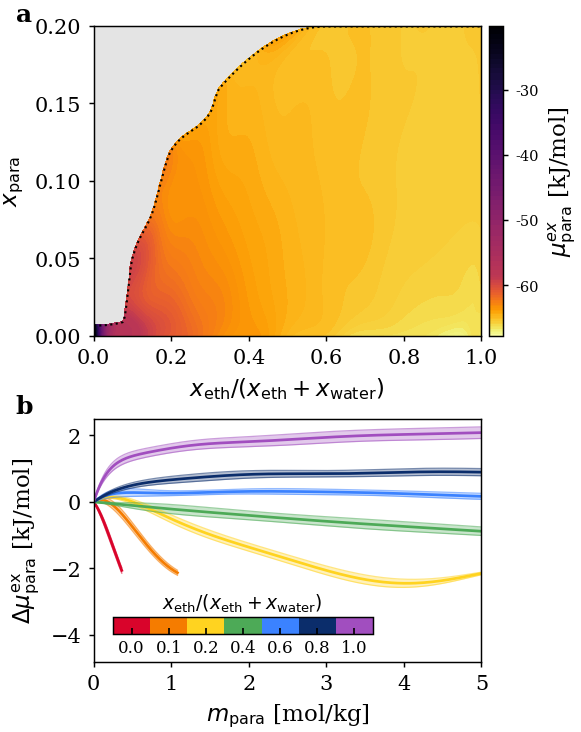

In [7]:
figA, (axA1, axA2) = plt.subplots(2, 1, figsize=(FIG_W, 5.2),
                                  gridspec_kw={"height_ratios": [2.8, 2.20]})
figA.subplots_adjust(left=0.15, right=CBAR_RIGHT, top=0.90, bottom=0.085, hspace=0.3)
# passing MU_NORM_PW is what selects spacing="proportional" in panel_muex_map, i.e. a bar that is
# linear in mu_ex with evenly spaced labels, over a piecewise colour ramp
panel_muex_map(axA1, mu=MU_MAP_FULL, bands=MU_BANDS_PW, ticks=MU_TICKS_PW, norm=MU_NORM_PW)
panel_muex_slices(axA2, key_rect=(0.05, 0.115, 0.67, 0.07))
panel_labels((axA1, axA2))
save(figA, "productionFigA_muex_v7")
plt.show()

## Figure B — total $\mu$ and the solubility of both polymorphs

Panel (a) adds the ideal term to $\mu^{ex}$ and reads off where each slice crosses a solid level;
panel (b) is that crossing as a function of solvent composition, **for Form I and Form II**. Both
quantities the crossing is read from carry their uncertainty: the curve bands are $\pm1$ Monte Carlo
standard deviation, and each solid level has a $\pm\sigma$ strip in its own colour, drawn like the
curve bands and keyed the same way.

Form II sits a factor of ~2.5 above Form I at every solvent composition — the metastable polymorph is
the more soluble one, which is what a $0.55$ kcal/mol difference in $\mu_\mathrm{solid}$ buys at
$k_BT = 0.60$ kcal/mol. Both literature series report Form I, so it is the lower curve they should be
compared against; the Form II curve is there to show the gap, not as a competing prediction. Its
presence is why the $y$ axis reaches ~4 mol/kg and the experimental points sit low in the panel.

**The $x$ axis of panel (b) is weight% ethanol**, solute free:

$$w_\mathrm{eth} = 100\,\frac{x\,M_\mathrm{EtOH}}{x\,M_\mathrm{EtOH} + (1-x)\,M_\mathrm{H_2O}},
\qquad x = \frac{x_\mathrm{eth}}{x_\mathrm{eth} + x_\mathrm{water}}$$

the basis the CSV's own `EtOH %(w/w, solute free)` column uses and the basis the CRC density table is
indexed by, so the experimental points, the mol/L → mol/kg conversion and the axis all sit on one
definition. The relabelling is monotone but not linear — 50 wt% ethanol is $x_\mathrm{eth} = 0.281$ —
so the co-solvency maximum appears further right than it does against mole fraction.

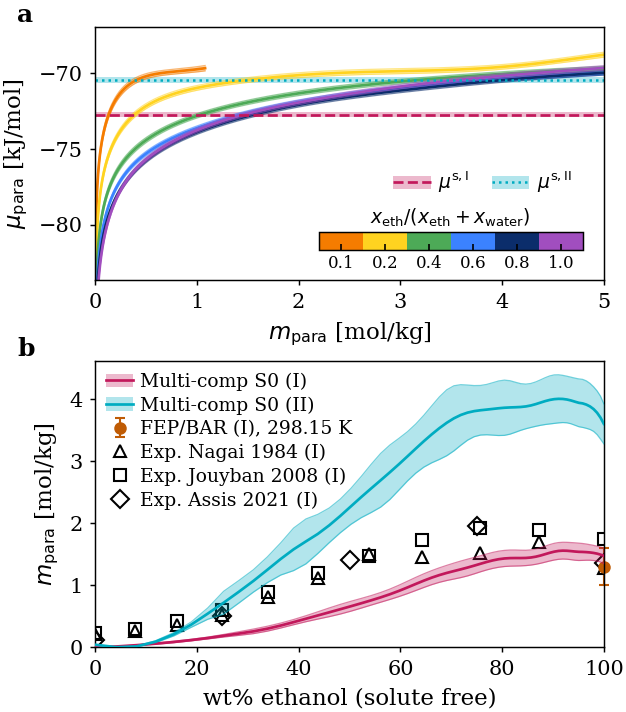

Form 1  m_para_sat [mol/kg]:
    x_eth=0.0:  5.26e-08  +-8.76e-09
    x_eth=0.1:     0.132  +-0.0145
    x_eth=0.2:     0.386  +-0.0418
    x_eth=0.4:      1.04  +-0.106
    x_eth=0.6:      1.43  +-0.13
    x_eth=0.8:      1.56  +-0.135
    x_eth=1.0:      1.46  +-0.126
Form 2  m_para_sat [mol/kg]:
    x_eth=0.0:   1.3e-07  +-2.16e-08
    x_eth=0.1:     0.406  +-0.0912
    x_eth=0.2:       1.5  +-0.343
    x_eth=0.4:      3.18  +-0.396
    x_eth=0.6:      3.87  +-0.44
    x_eth=0.8:      4.01  +-0.388
    x_eth=1.0:      3.56  +-0.323
Jouyban     experiment  [mol/kg]:  pure water 0.226   pure ethanol 1.742   max 1.915
Prakongpan  experiment  [mol/kg]:  pure water 0.207   pure ethanol 1.272   max 1.689
Assis       experiment  [mol/kg]:  pure water 0.111   pure ethanol 1.361   max 1.959


In [8]:
figB, (axB1, axB2) = plt.subplots(2, 1, figsize=(FIG_W, 4.7),
                                  gridspec_kw={"height_ratios": [1.95, 2.2]})
figB.subplots_adjust(left=0.15, right=0.97, top=0.98, bottom=0.10, hspace=0.30)
panel_mu_total(axB1)
panel_solubility(axB2)
panel_labels((axB1, axB2))
save(figB, "productionFigB_solubility_v7")
plt.show()

# +- is one Monte Carlo standard deviation over splits + anchors + mu_solid
for form in (1, 2):
    print(f"{FORM_NAME[form]:7s} m_para_sat [mol/kg]:")
    for s in SLICES:
        i = int(np.argmin(np.abs(SF_SOL - s)))
        print(f"    x_eth={s:.1f}: {SOL[form][i]:>9.3g}  +-{SD_SOL[form][i]:.3g}")
for name, (xe, m_para) in EXP.items():
    print(f"{name:11s} experiment  [mol/kg]:  pure water {m_para[0]:.3f}   "
          f"pure ethanol {m_para[-1]:.3f}   max {m_para.max():.3f}")

## Solubility summary

Saturation molality in pure water, in pure ethanol, and at the co-solvency maximum with the solvent
composition it sits at, on both the mole-fraction and the weight% basis — for both polymorphs, each
with a `sd` column holding one Monte Carlo standard deviation, and the literature series summarised
the same way. Written to `v7_solubility_summary.csv`.

The `sd` is a symmetric summary of a spread that is not always symmetric. It is a fair description
for the molality rows; for the **peak position** it is not, because Form I's maximum sits at
$x_\mathrm{eth} \approx 0.96$ and the samples can move it far down the composition axis but hardly
at all up — the plateau runs into pure ethanol. The `wt%` row's $\sigma$ is the $x_\mathrm{eth}$ one
carried through the non-linear relabelling, so it is a half-width rather than a true standard
deviation.

`SF_SOL` is spaced 0.02, too coarse to quote a peak position from, so the central maximum is
re-located on a fine grid spanning the two neighbours of the coarse argmax, and each Monte Carlo
sample's maximum is refined to the vertex of the parabola through its own three points. Both are
sub-grid, which matters: quantised to 0.02 the interval can fail to bracket the value it is quoted
with.

Both maxima are broad plateaux rather than sharp peaks — the curve is flat to within its own band
across much of the ethanol-rich half — so read the plateau, not the argmax.

In [9]:
def sat_peak(mu, mu_solid, n=41):
    """(x_eth, m_para) at the co-solvency maximum of one surface, refined off the SF_SOL grid.

    Coarse pass on SF_SOL, then a fine scan across the bracket around the argmax -- the SF_SOL
    spacing of 0.02 is too coarse to quote a peak position from. `nanargmax` because `m_sat_rows`
    returns NaN where there is no upward crossing, and the bracket is clipped so a peak landing on
    an endpoint still resolves. The fine scan re-evaluates the GP, the only place after the
    precompute cell that happens.
    """
    coarse = m_sat_rows(mu, mu_solid)
    i = int(np.nanargmax(coarse))
    fine = np.linspace(SF_SOL[max(i - 1, 0)], SF_SOL[min(i + 1, len(SF_SOL) - 1)], n)
    xf, sff = np.meshgrid(XP_SOL, fine)
    mu_fine = mu_ex_grid(GP, xf, sff * (1.0 - xf))
    d = mu_fine + IDEAL_SOL - mu_solid
    up = np.diff(np.sign(d), axis=-1) > 0
    j = np.argmax(up, axis=-1)
    r = np.arange(len(fine))
    d0, d1 = d[r, j], d[r, j + 1]
    x = XP_SOL[j] - d0 * (XP_SOL[j + 1] - XP_SOL[j]) / (d1 - d0)
    m = np.where(up.any(axis=-1) & (d[:, 0] <= 0.0), molality(x, fine), np.nan)
    k = int(np.nanargmax(m))
    return float(fine[k]), float(m[k])


PEAK = {form: sat_peak(CUBE_SOL[0], MU_SOLID[form]) for form in (1, 2)}

# endpoints located by argmin rather than by index, so this survives a change to SF_SOL
_IW = int(np.argmin(np.abs(SF_SOL - 0.0)))  # pure water
_IE = int(np.argmin(np.abs(SF_SOL - 1.0)))  # pure ethanol

_cols = {}
for form in (1, 2):
    _x_pk, _m_pk = PEAK[form]
    _sx, _sm = SD_PEAK[form]
    # the wt% row's s.d. is the x_eth one carried through the (monotone, non-linear) relabelling,
    # so it is the half-width of the interval rather than a symmetric error about the wt% value
    _s_wt = 0.5 * abs(float(wt_pct_eth(_x_pk + _sx)) - float(wt_pct_eth(_x_pk - _sx)))
    _cols[FORM_NAME[form]] = [SOL[form][_IW], SOL[form][_IE], _m_pk, _x_pk,
                              float(wt_pct_eth(_x_pk))]
    _cols[FORM_NAME[form] + " sd"] = [SD_SOL[form][_IW], SD_SOL[form][_IE], _sm, _sx, _s_wt]
for _name, (_xe, _m) in EXP.items():
    _k = int(np.nanargmax(_m))
    _cols["exp: " + _name] = [float(_m[int(np.argmin(np.abs(_xe - 0.0)))]),
                              float(_m[int(np.argmin(np.abs(_xe - 1.0)))]),
                              float(_m[_k]), float(_xe[_k]), float(wt_pct_eth(_xe[_k]))]

SOL_SUMMARY = pd.DataFrame(_cols, index=["pure water [mol/kg]", "pure ethanol [mol/kg]",
                                         "maximum [mol/kg]", "x_eth at maximum",
                                         "wt% ethanol at maximum"])
SOL_SUMMARY.to_csv(FIG_DIR / "v7_solubility_summary.csv")

# 4 significant figures rather than a fixed number of decimals: the values span 5e-8 to 4, and
# rounding would collapse the water endpoint to zero
display(SOL_SUMMARY.apply(lambda c: c.map(lambda v: "" if pd.isna(v) else f"{v:.4g}")))

_ref_max = float(np.nanmax(EXP["Jouyban"][1]))
print("=" * 78)
for form in (1, 2):
    _x_pk, _m_pk = PEAK[form]
    _sx, _sm = SD_PEAK[form]
    print(f"{FORM_NAME[form]}: max {_m_pk:.3f} +-{_sm:.3f} mol/kg at x_eth = "
          f"{_x_pk:.3f} +-{_sx:.3f} ({wt_pct_eth(_x_pk):.1f} wt% ethanol)   "
          f"{_m_pk / SOL[form][_IE]:.2f}x pure ethanol, {_m_pk / _ref_max:.2f}x exp. max")
print(f"Form 2 / Form 1 at the maximum: {PEAK[2][1] / PEAK[1][1]:.2f}x  -- the polymorph gap the")
print("solubility panel now shows directly, from a difference in mu_solid of "
      f"{MU_SOLID[2] - MU_SOLID[1]:.3f} {E_UNIT}.")
print("Both polymorphs put the co-solvency maximum in the ethanol-rich half, as a broad plateau")
print("rather than a sharp peak: the curve is flat to within its own band over a wide window, so")
print("the argmax above is less meaningful than the plateau it sits on.")

print("Reference values used (kcal/mol):  "
      f"mu^s,I {MU_SOLID_KCAL[1]:.4f} +-{SIGMA_MU_SOLID_KCAL[1]:.4f},  "
      f"mu^s,II {MU_SOLID_KCAL[2]:.4f} +-{SIGMA_MU_SOLID_KCAL[2]:.4f}")
print("                     anchors (eV):  " + ",  ".join(
    f"{k} {ANCHORS[k][1]:.6f} +-{SIGMA_ANCHOR_EV[k]:.6f}" for k in ANCHOR_KEYS))
print("=" * 78)

,Form 1,Form 1 sd,Form 2,Form 2 sd,exp: Jouyban,exp: Prakongpan,exp: Assis
pure water [mol/kg],5.263e-08,8.755e-09,1.303e-07,2.164e-08,0.2258,0.207,0.1112
pure ethanol [mol/kg],1.459,0.1261,3.561,0.3231,1.742,1.272,1.361
maximum [mol/kg],1.555,0.1365,4.017,0.405,1.915,1.689,1.959
x_eth at maximum,0.8025,0.04773,0.7842,0.06451,0.5485,0.7268,0.5398
wt% ethanol at maximum,91.22,2.415,90.28,3.351,75.65,87.18,75


Form 1: max 1.555 +-0.136 mol/kg at x_eth = 0.802 +-0.048 (91.2 wt% ethanol)   1.07x pure ethanol, 0.81x exp. max
Form 2: max 4.017 +-0.405 mol/kg at x_eth = 0.784 +-0.065 (90.3 wt% ethanol)   1.13x pure ethanol, 2.10x exp. max
Form 2 / Form 1 at the maximum: 2.58x  -- the polymorph gap the
solubility panel now shows directly, from a difference in mu_solid of 2.286 kJ/mol.
Both polymorphs put the co-solvency maximum in the ethanol-rich half, as a broad plateau
rather than a sharp peak: the curve is flat to within its own band over a wide window, so
the argmax above is less meaningful than the plateau it sits on.
Reference values used (kcal/mol):  mu^s,I -17.3864 +-0.0413,  mu^s,II -16.8401 +-0.0403
                     anchors (eV):  water -0.238273 +-0.003903,  ethanol -0.687761 +-0.001440


In [10]:
1

1